[17:42:21] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[17:42:21] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[17:42:21] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[17:42:21] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

num_node_features = 152
num_y_ATs = 75
FULL DATASET:


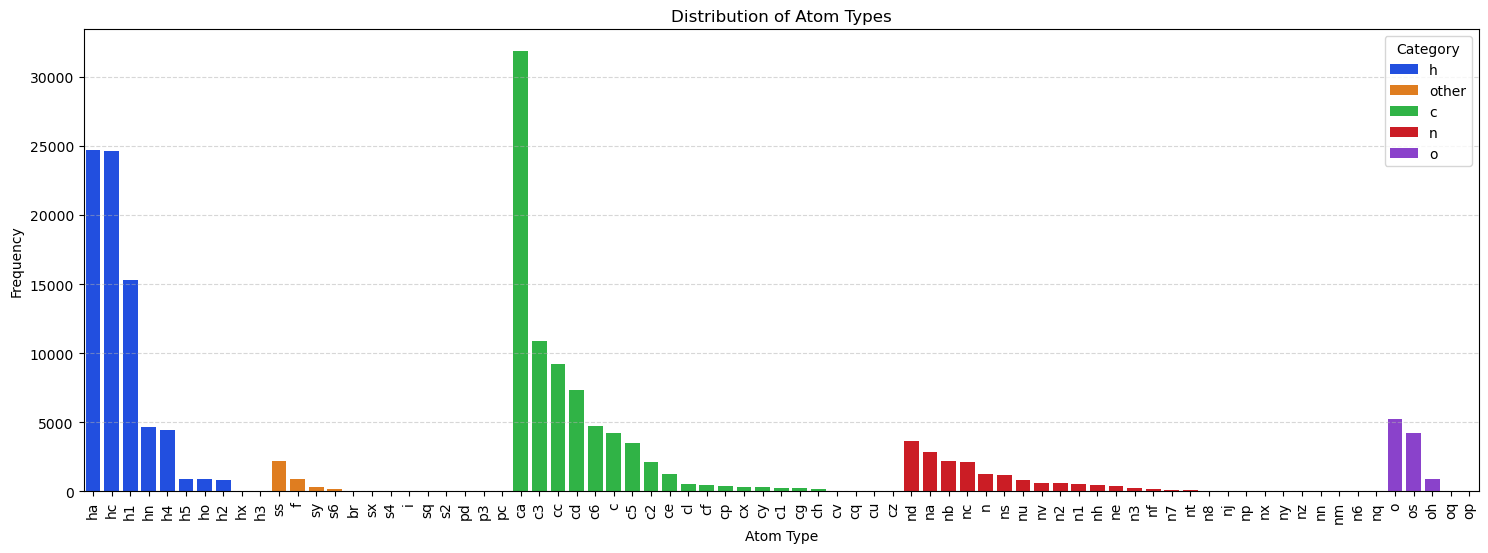

BaselineGAT - Number of parameters: 1406027


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.5700 | Val Loss: 0.5936
Epoch - 20: Train Loss: 0.5106 | Val Loss: 0.5349


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.4754 | Val Loss: 0.4889
Epoch - 20: Train Loss: 0.4731 | Val Loss: 0.4836


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.4550 | Val Loss: 0.4590
Epoch - 20: Train Loss: 0.4523 | Val Loss: 0.4700


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.4521 | Val Loss: 0.4540
Epoch - 20: Train Loss: 0.4446 | Val Loss: 0.4494


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.4412 | Val Loss: 0.4495
Epoch - 20: Train Loss: 0.4378 | Val Loss: 0.4508


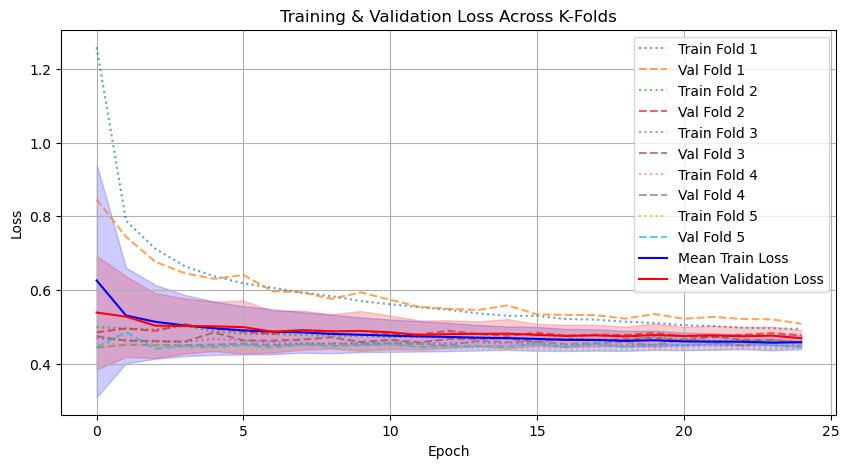

Evaluation Metrics: {'Accuracy': 0.8233675121424716, 'F1-score': 0.8078788142804255}


In [1]:
from atoMLtype.GNN.GNNmodel import GNNTrainer, BaselineGAT
from atoMLtype.GNN.GNNdataset import GNNdataset
from atoMLtype.utils.metrics import plot_atom_distribution, plot_full_heatmap
from torch.utils.data import random_split
import numpy as np

# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
gnn_test_dataset = GNNdataset(sdf_path, json_labels)
num_node_feat = gnn_test_dataset[0].x.shape[1]
num_y_ATs = len(set(gnn_test_dataset.all_labels))

print(f"num_node_features = {num_node_feat}")
print(f"num_y_ATs = {num_y_ATs}")


# Split Train and test dataset (95% train, 5% test)
train_size = int(0.90 * len(gnn_test_dataset))
test_size = len(gnn_test_dataset) - train_size
train_dataset, test_dataset = random_split(gnn_test_dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(gnn_test_dataset.all_labels))

# Initialize baselineGNN for classification
model_GAT = BaselineGAT(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512, heads=4)
trainer_GAT = GNNTrainer(model_GAT, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=25, k_folds=5, task="classification", random_seed=21)
trainer_GAT.train()
metrics_GAT = trainer_GAT.evaluate_model(test_dataset)

y_true_GAT, y_pred_GAT = trainer_GAT.predict(test_dataset)

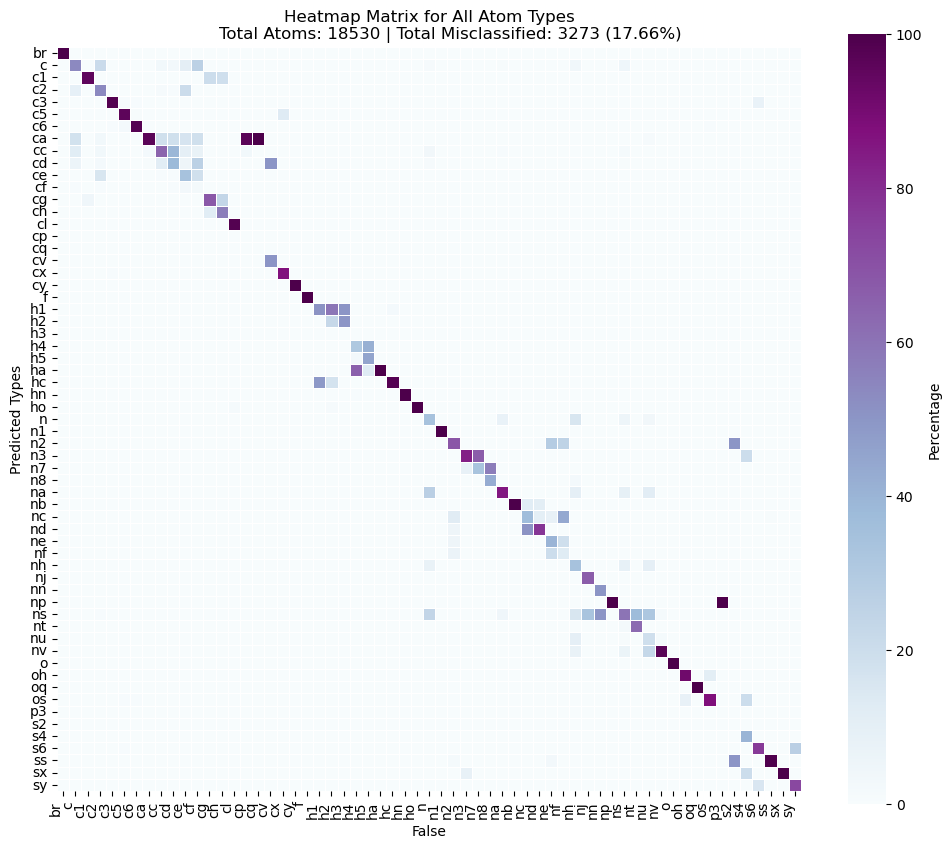

In [2]:
plot_full_heatmap(y_true=y_true_GAT, y_pred=y_pred_GAT)

MPNN_4L - Number of parameters: 133227


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.5698 | Val Loss: 0.5170
Epoch - 20: Train Loss: 0.4984 | Val Loss: 0.4705
Epoch - 30: Train Loss: 0.4682 | Val Loss: 0.4544


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.4539 | Val Loss: 0.4296
Epoch - 20: Train Loss: 0.4414 | Val Loss: 0.4274
Epoch - 30: Train Loss: 0.4307 | Val Loss: 0.4198


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.4222 | Val Loss: 0.4007
Epoch - 20: Train Loss: 0.4140 | Val Loss: 0.3965
Epoch - 30: Train Loss: 0.4087 | Val Loss: 0.3940


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.4064 | Val Loss: 0.3826
Epoch - 20: Train Loss: 0.3988 | Val Loss: 0.3817
Epoch - 30: Train Loss: 0.3949 | Val Loss: 0.3838


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.3930 | Val Loss: 0.3783
Epoch - 20: Train Loss: 0.3870 | Val Loss: 0.3797
Epoch - 30: Train Loss: 0.3854 | Val Loss: 0.3841


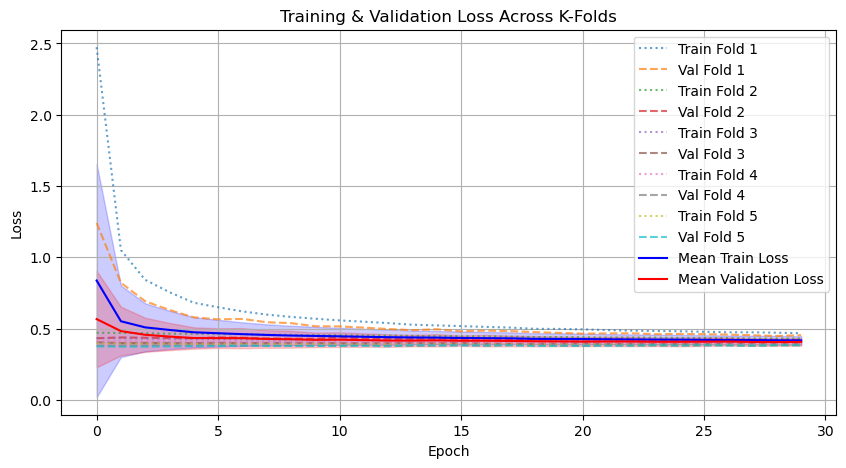

Evaluation Metrics: {'Accuracy': 0.854020507285483, 'F1-score': 0.8441882913118312}


In [6]:
from atoMLtype.GNN.GNNmodel import MPNN_4L

# Initialize baselineGNN for classification
model_MPNN_4L = MPNN_4L(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=128)
trainer_MPNN_4L = GNNTrainer(model_MPNN_4L, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_MPNN_4L.train()
metrics_MPNN_4L = trainer_MPNN_4L.evaluate_model(test_dataset)

y_true_MPNN_4L, y_pred_MPNN_4L = trainer_MPNN_4L.predict(test_dataset)

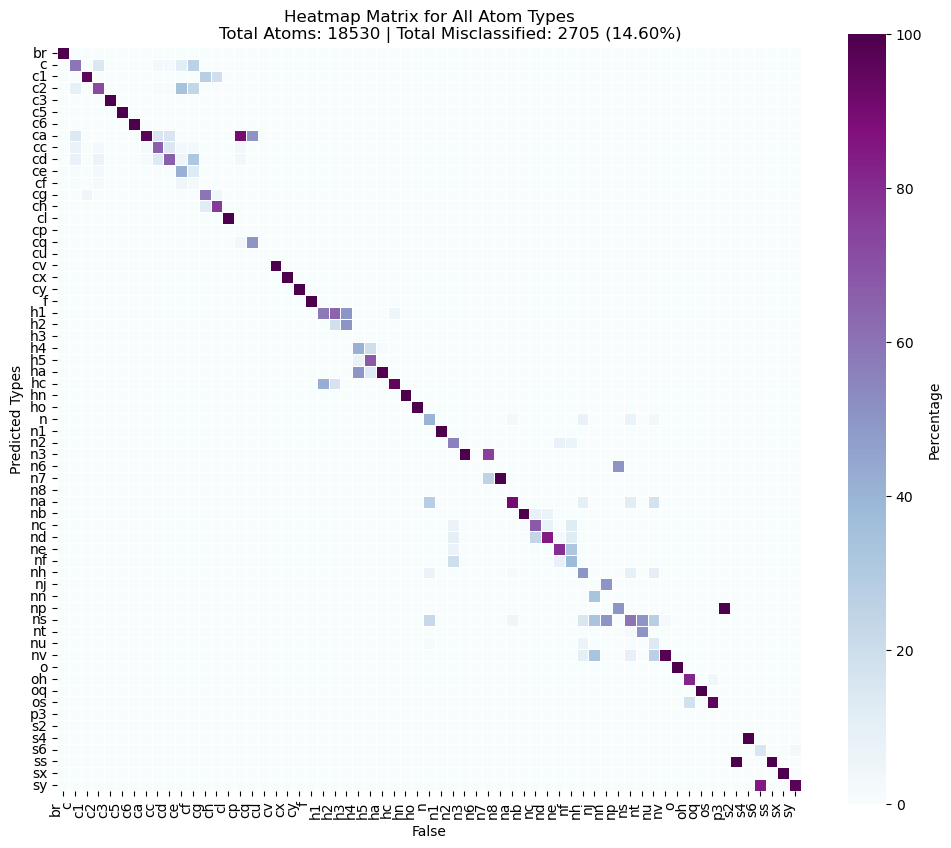

In [7]:

plot_full_heatmap(y_true=y_true_MPNN_4L, y_pred=y_pred_MPNN_4L)

# MISCLASSIFICATION EXPLORATION

## GAT CLASSIFICATIONS

In [8]:
import importlib
import atoMLtype.utils.metrics
importlib.reload(atoMLtype.utils.metrics)
from atoMLtype.utils.metrics import plot_atom_distribution, plot_full_heatmap, \
    plot_category_heatmap, plot_detailed_cross_category_heatmap, \
    plot_full_cross_intra_confusion_matices, plot_category_confusion_matrices

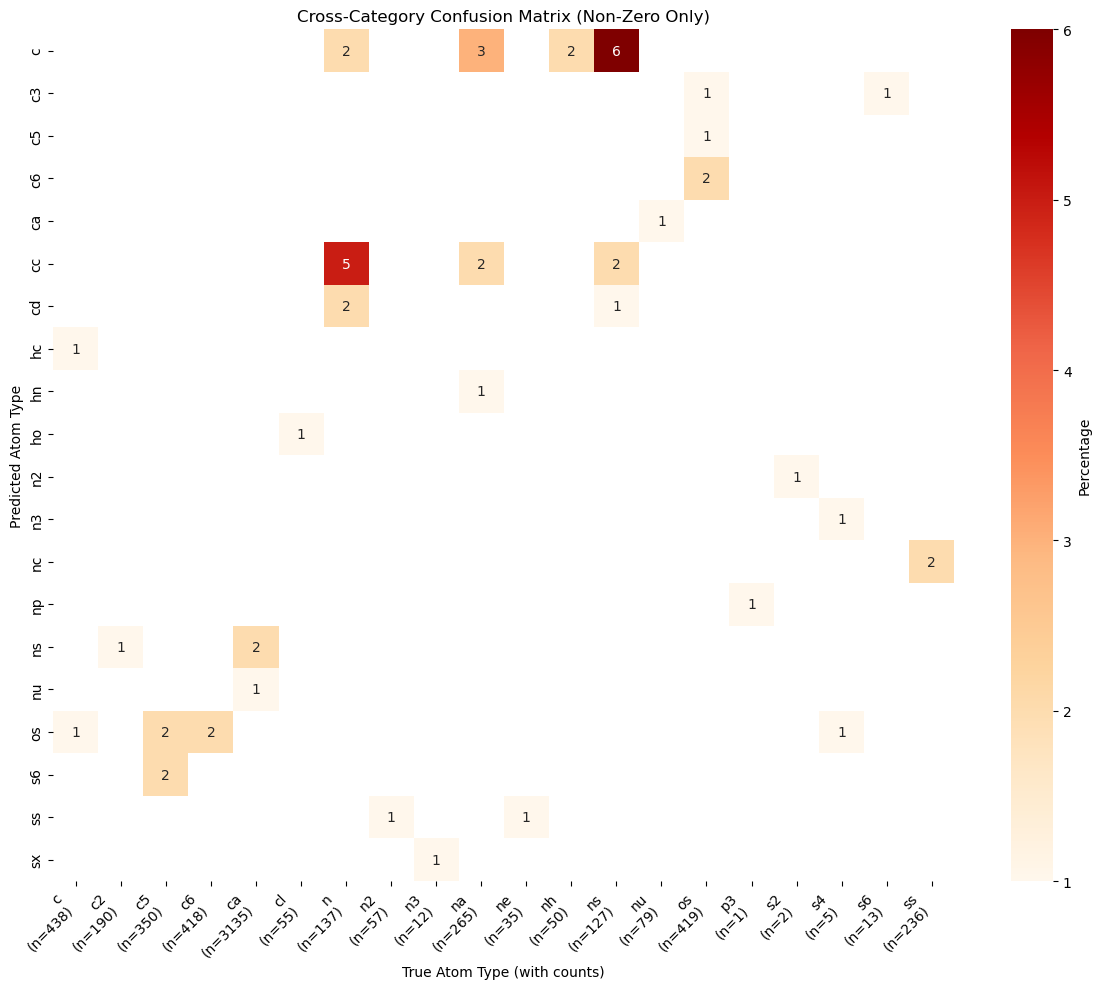

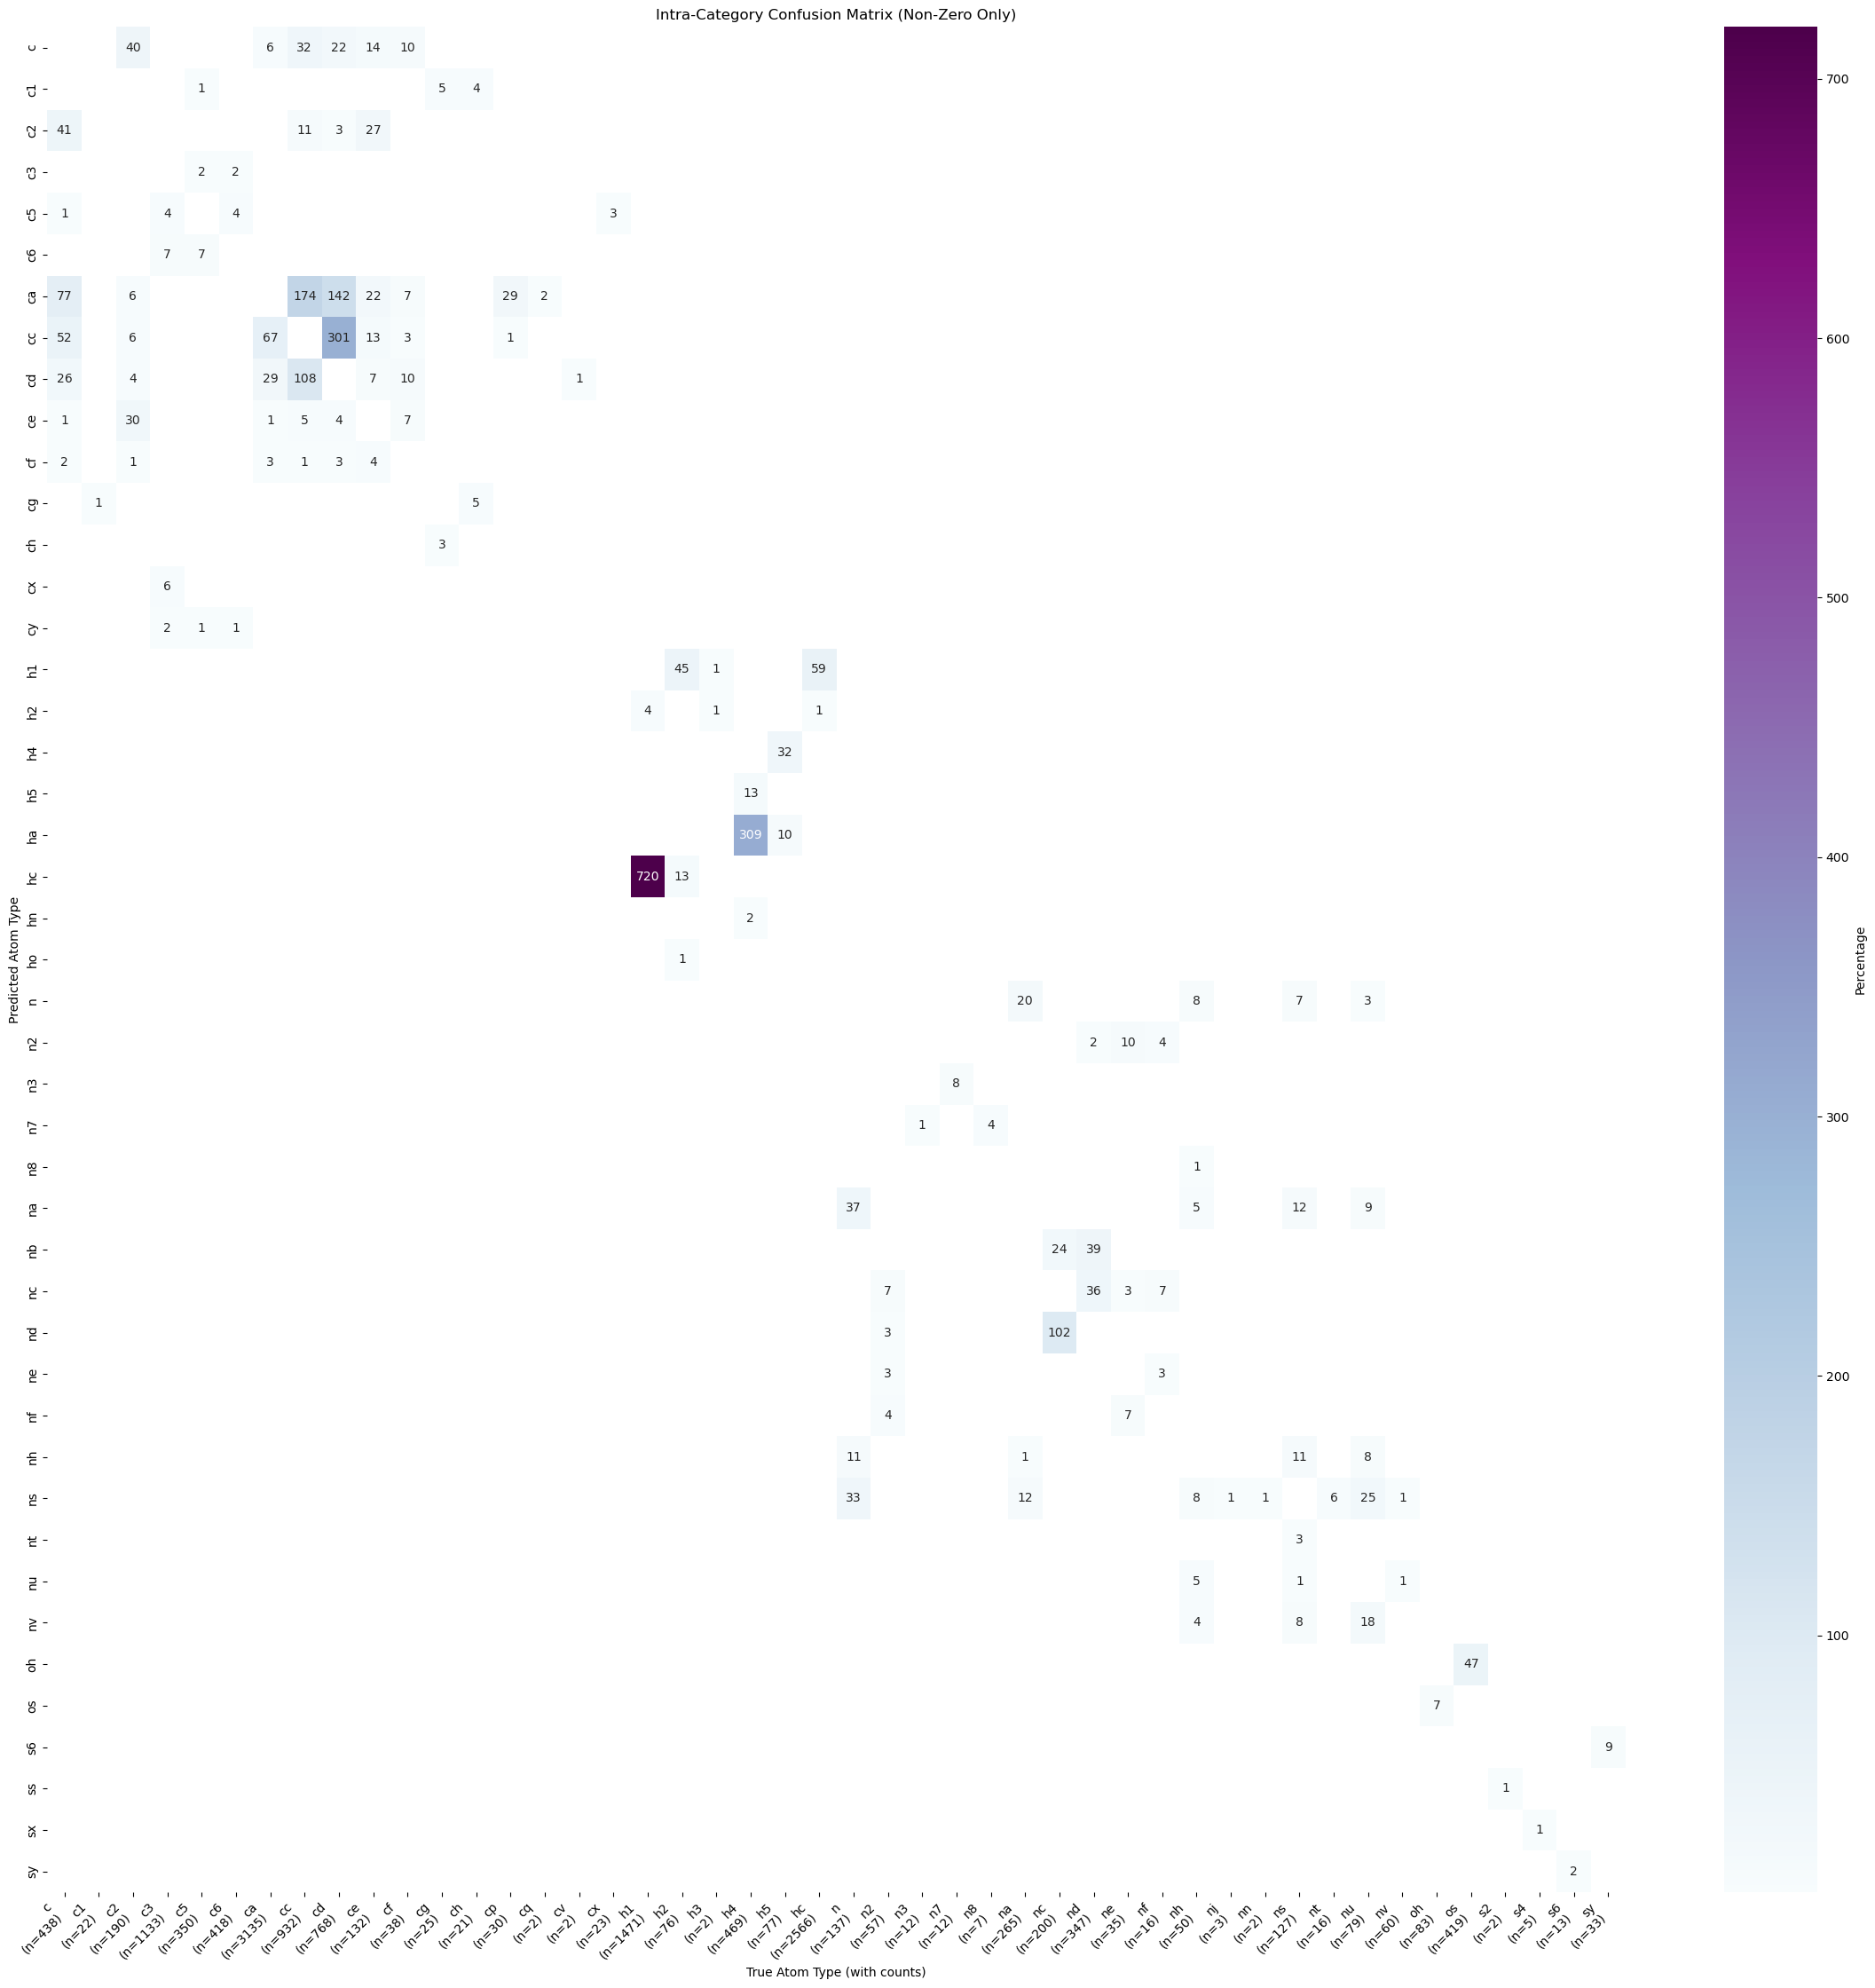

In [9]:
plot_full_cross_intra_confusion_matices(y_true=y_true_GAT, y_pred=y_pred_GAT)

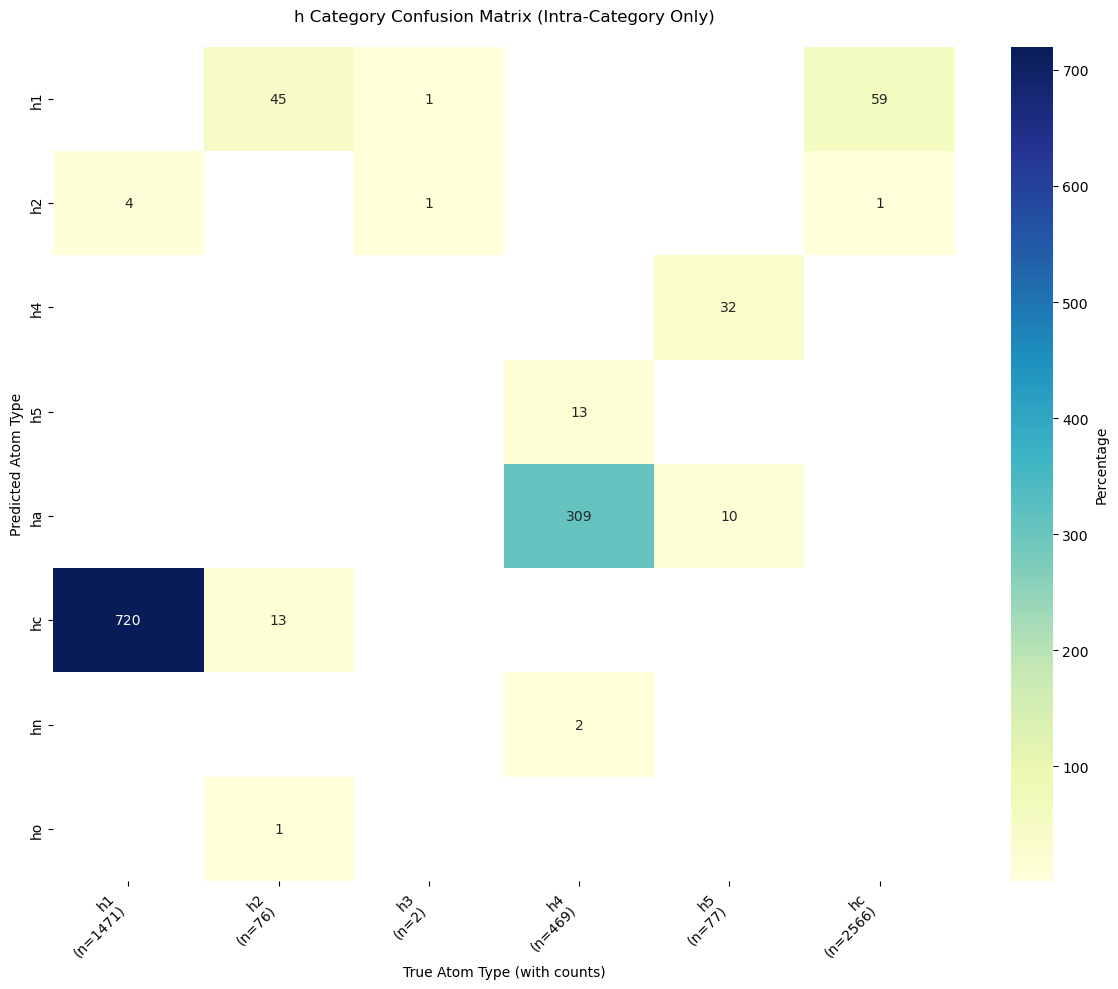

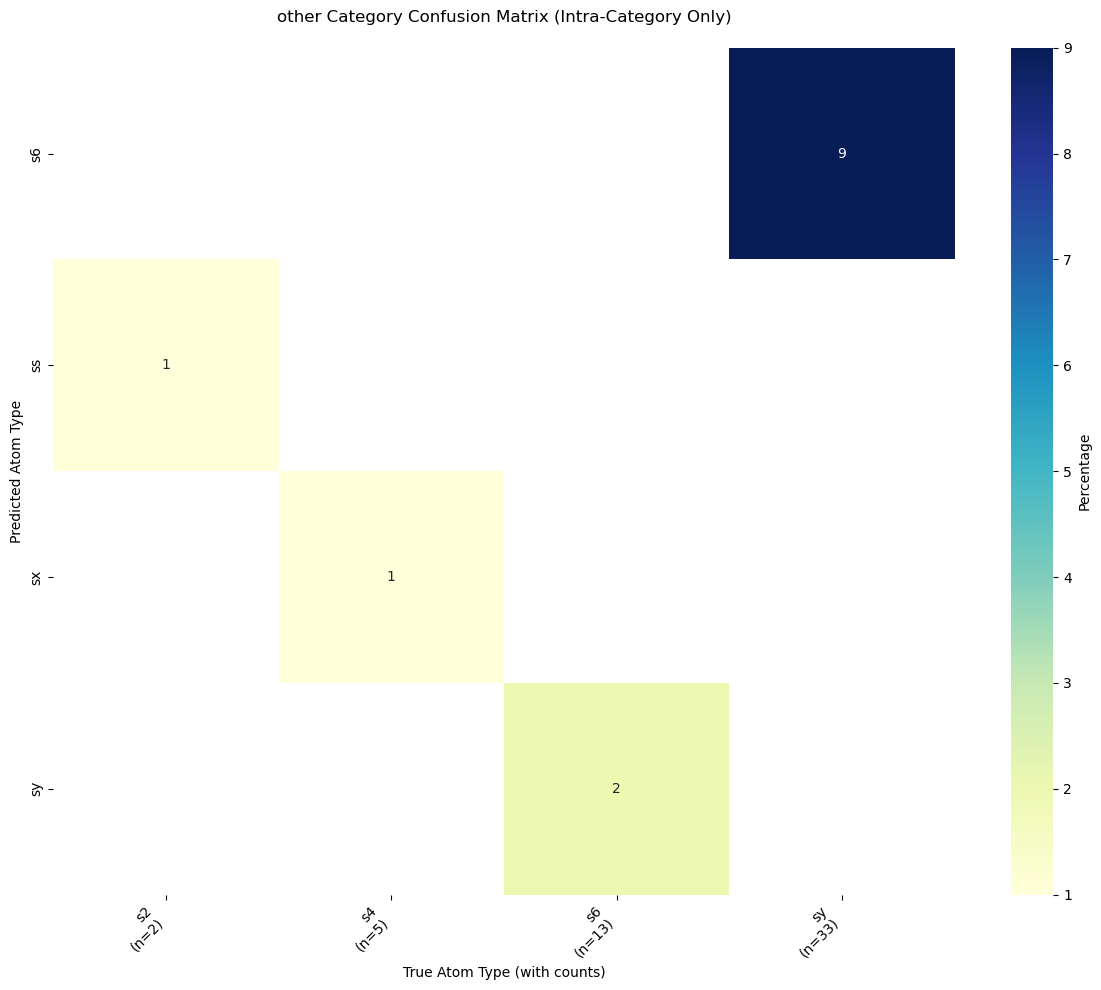

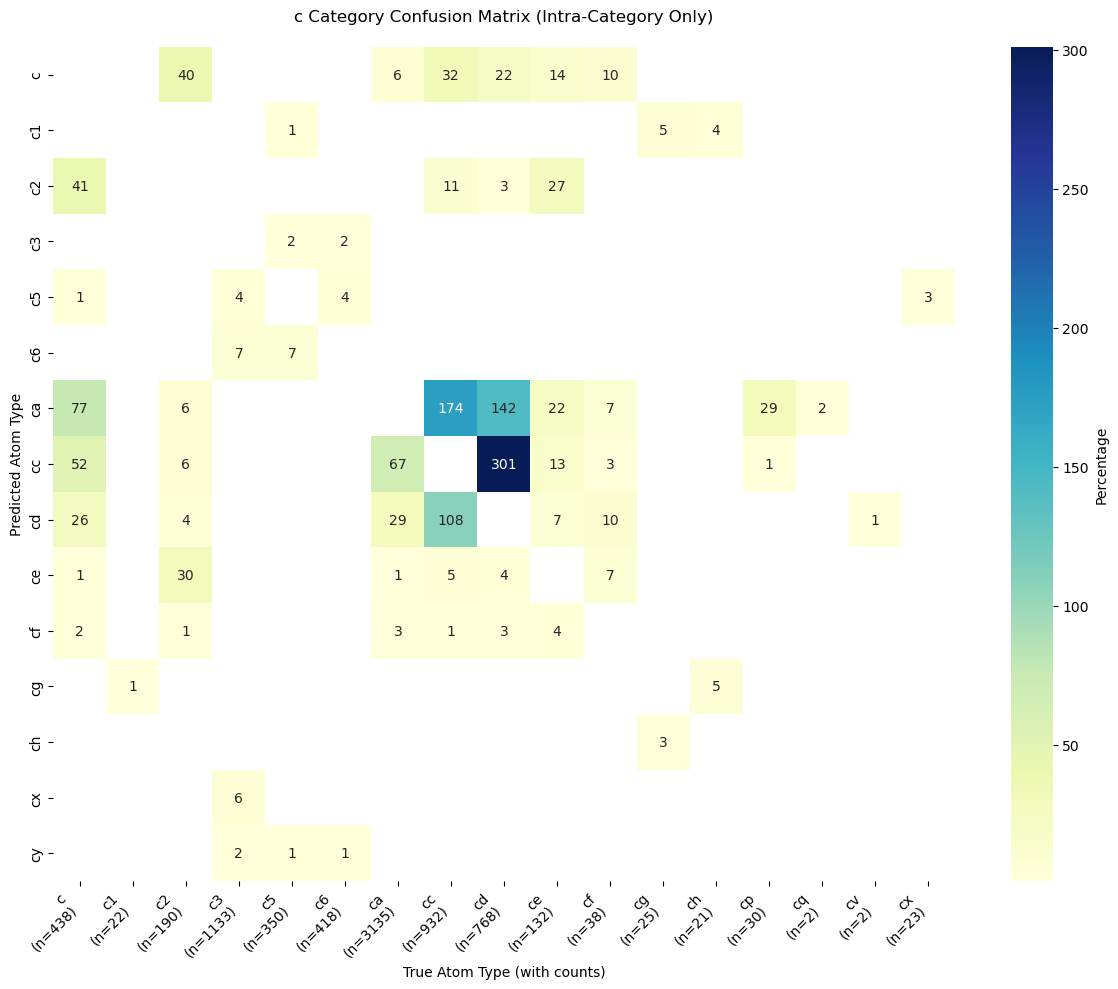

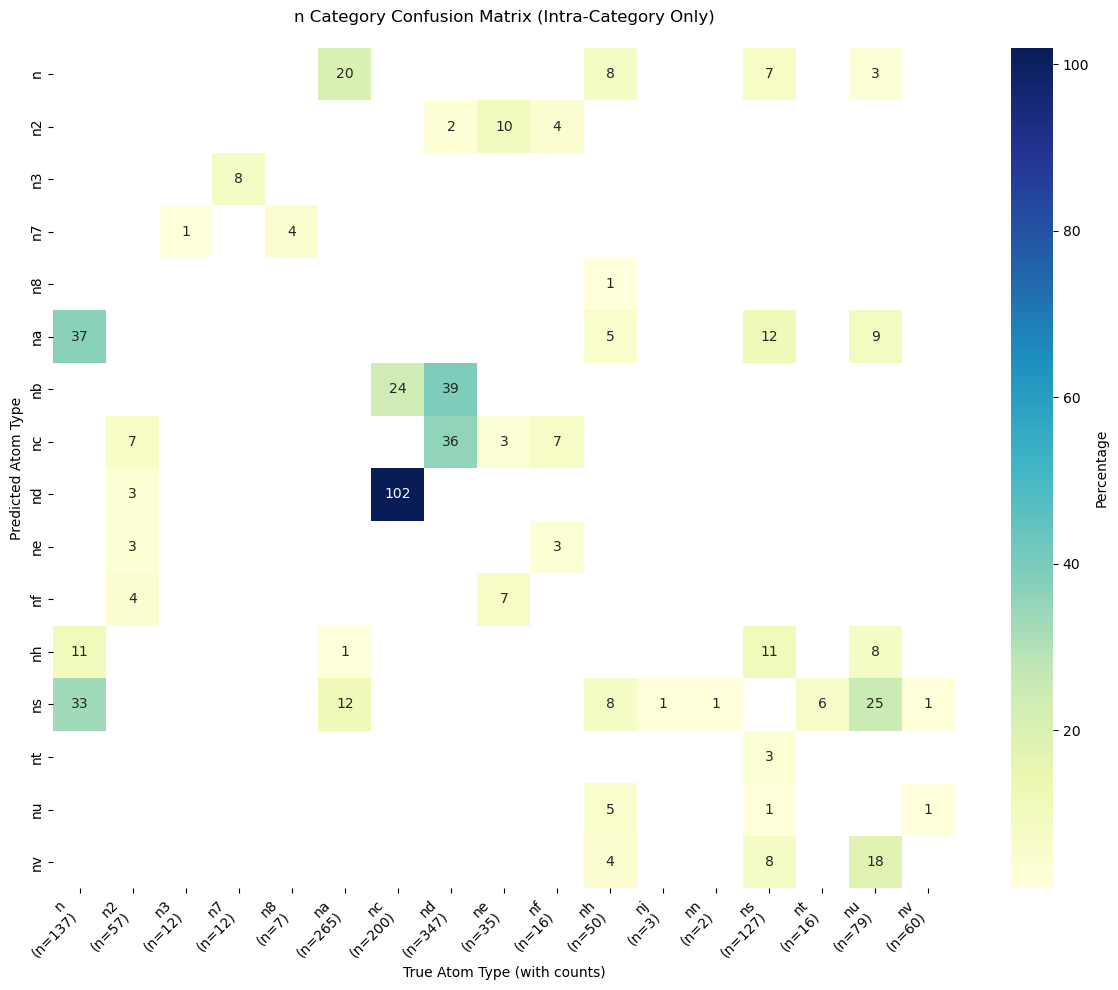

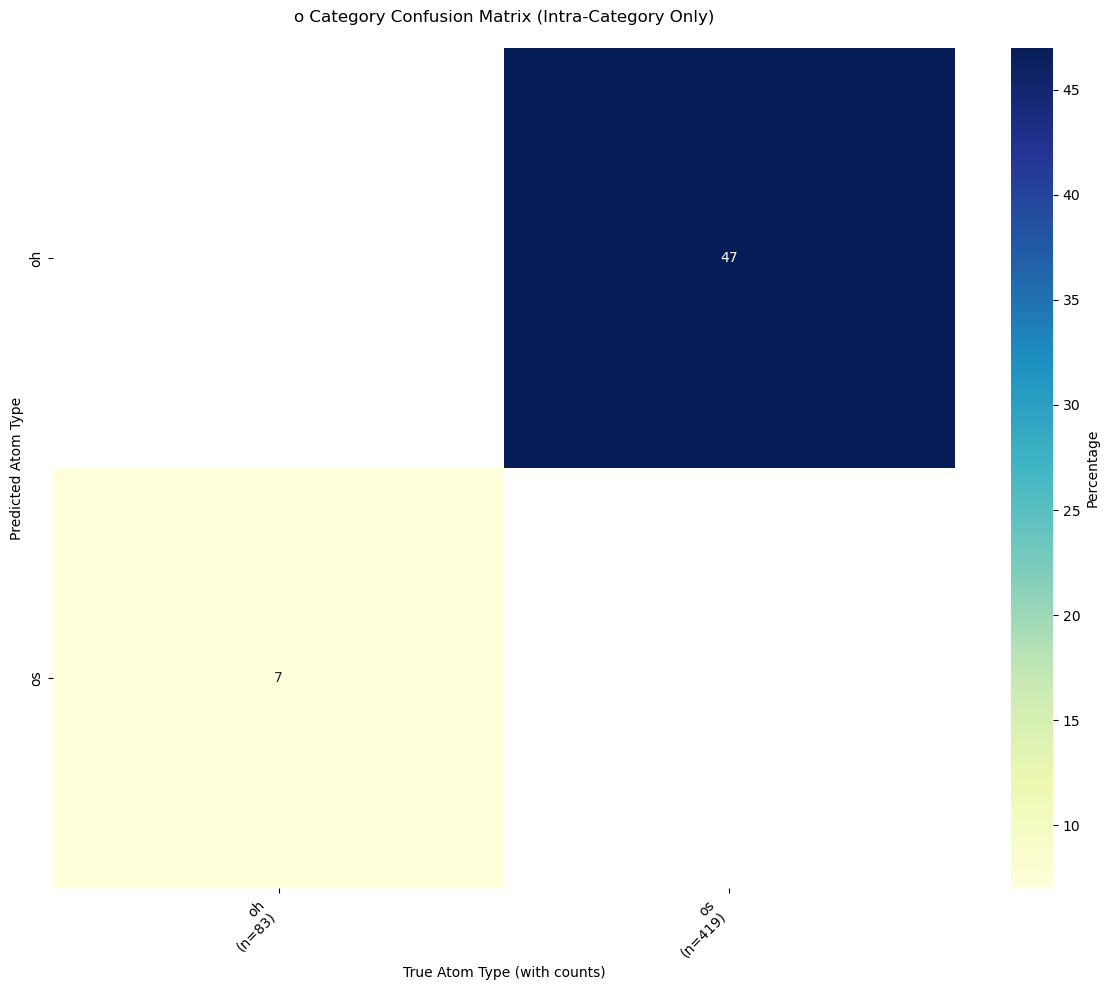

In [10]:
plot_category_confusion_matrices(y_true=y_true_GAT, y_pred=y_pred_GAT)

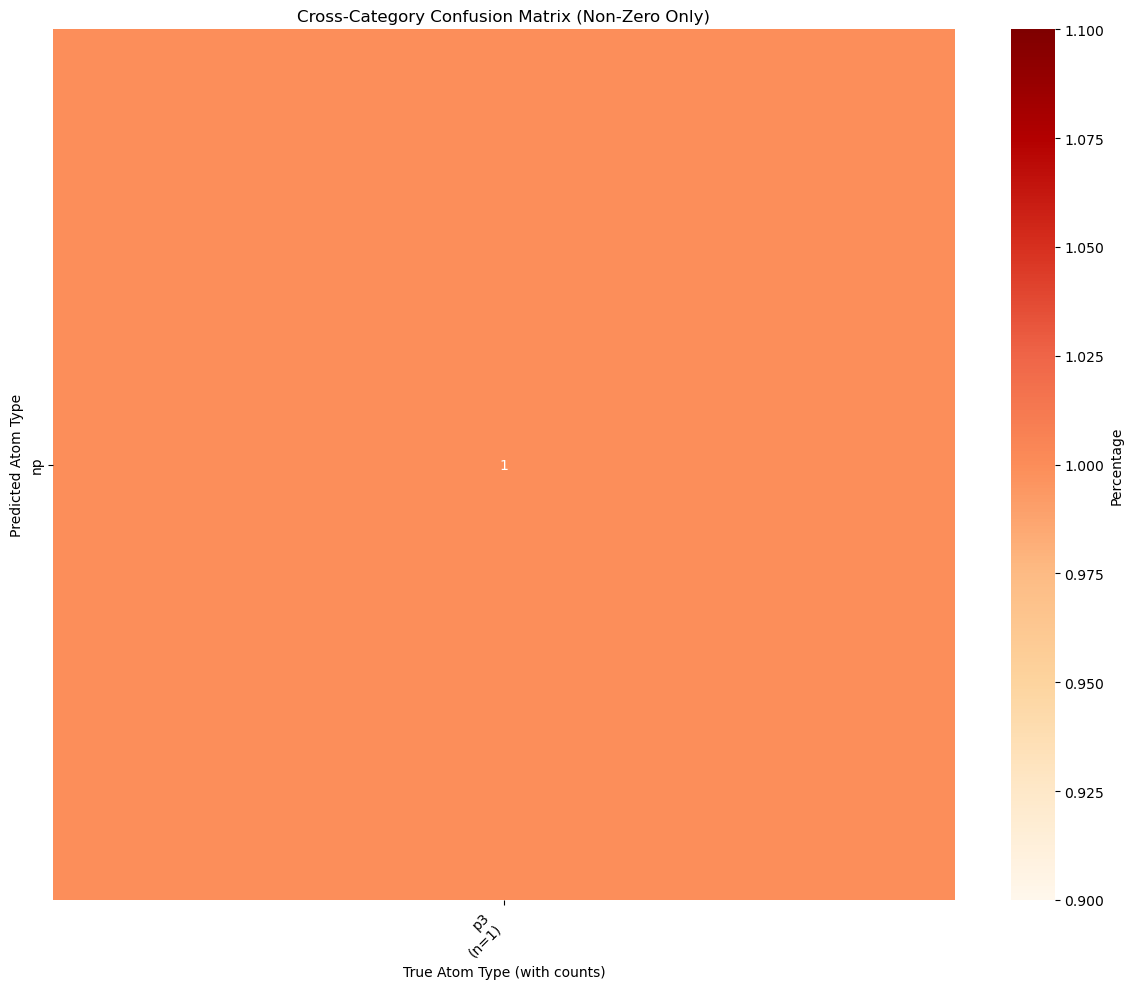

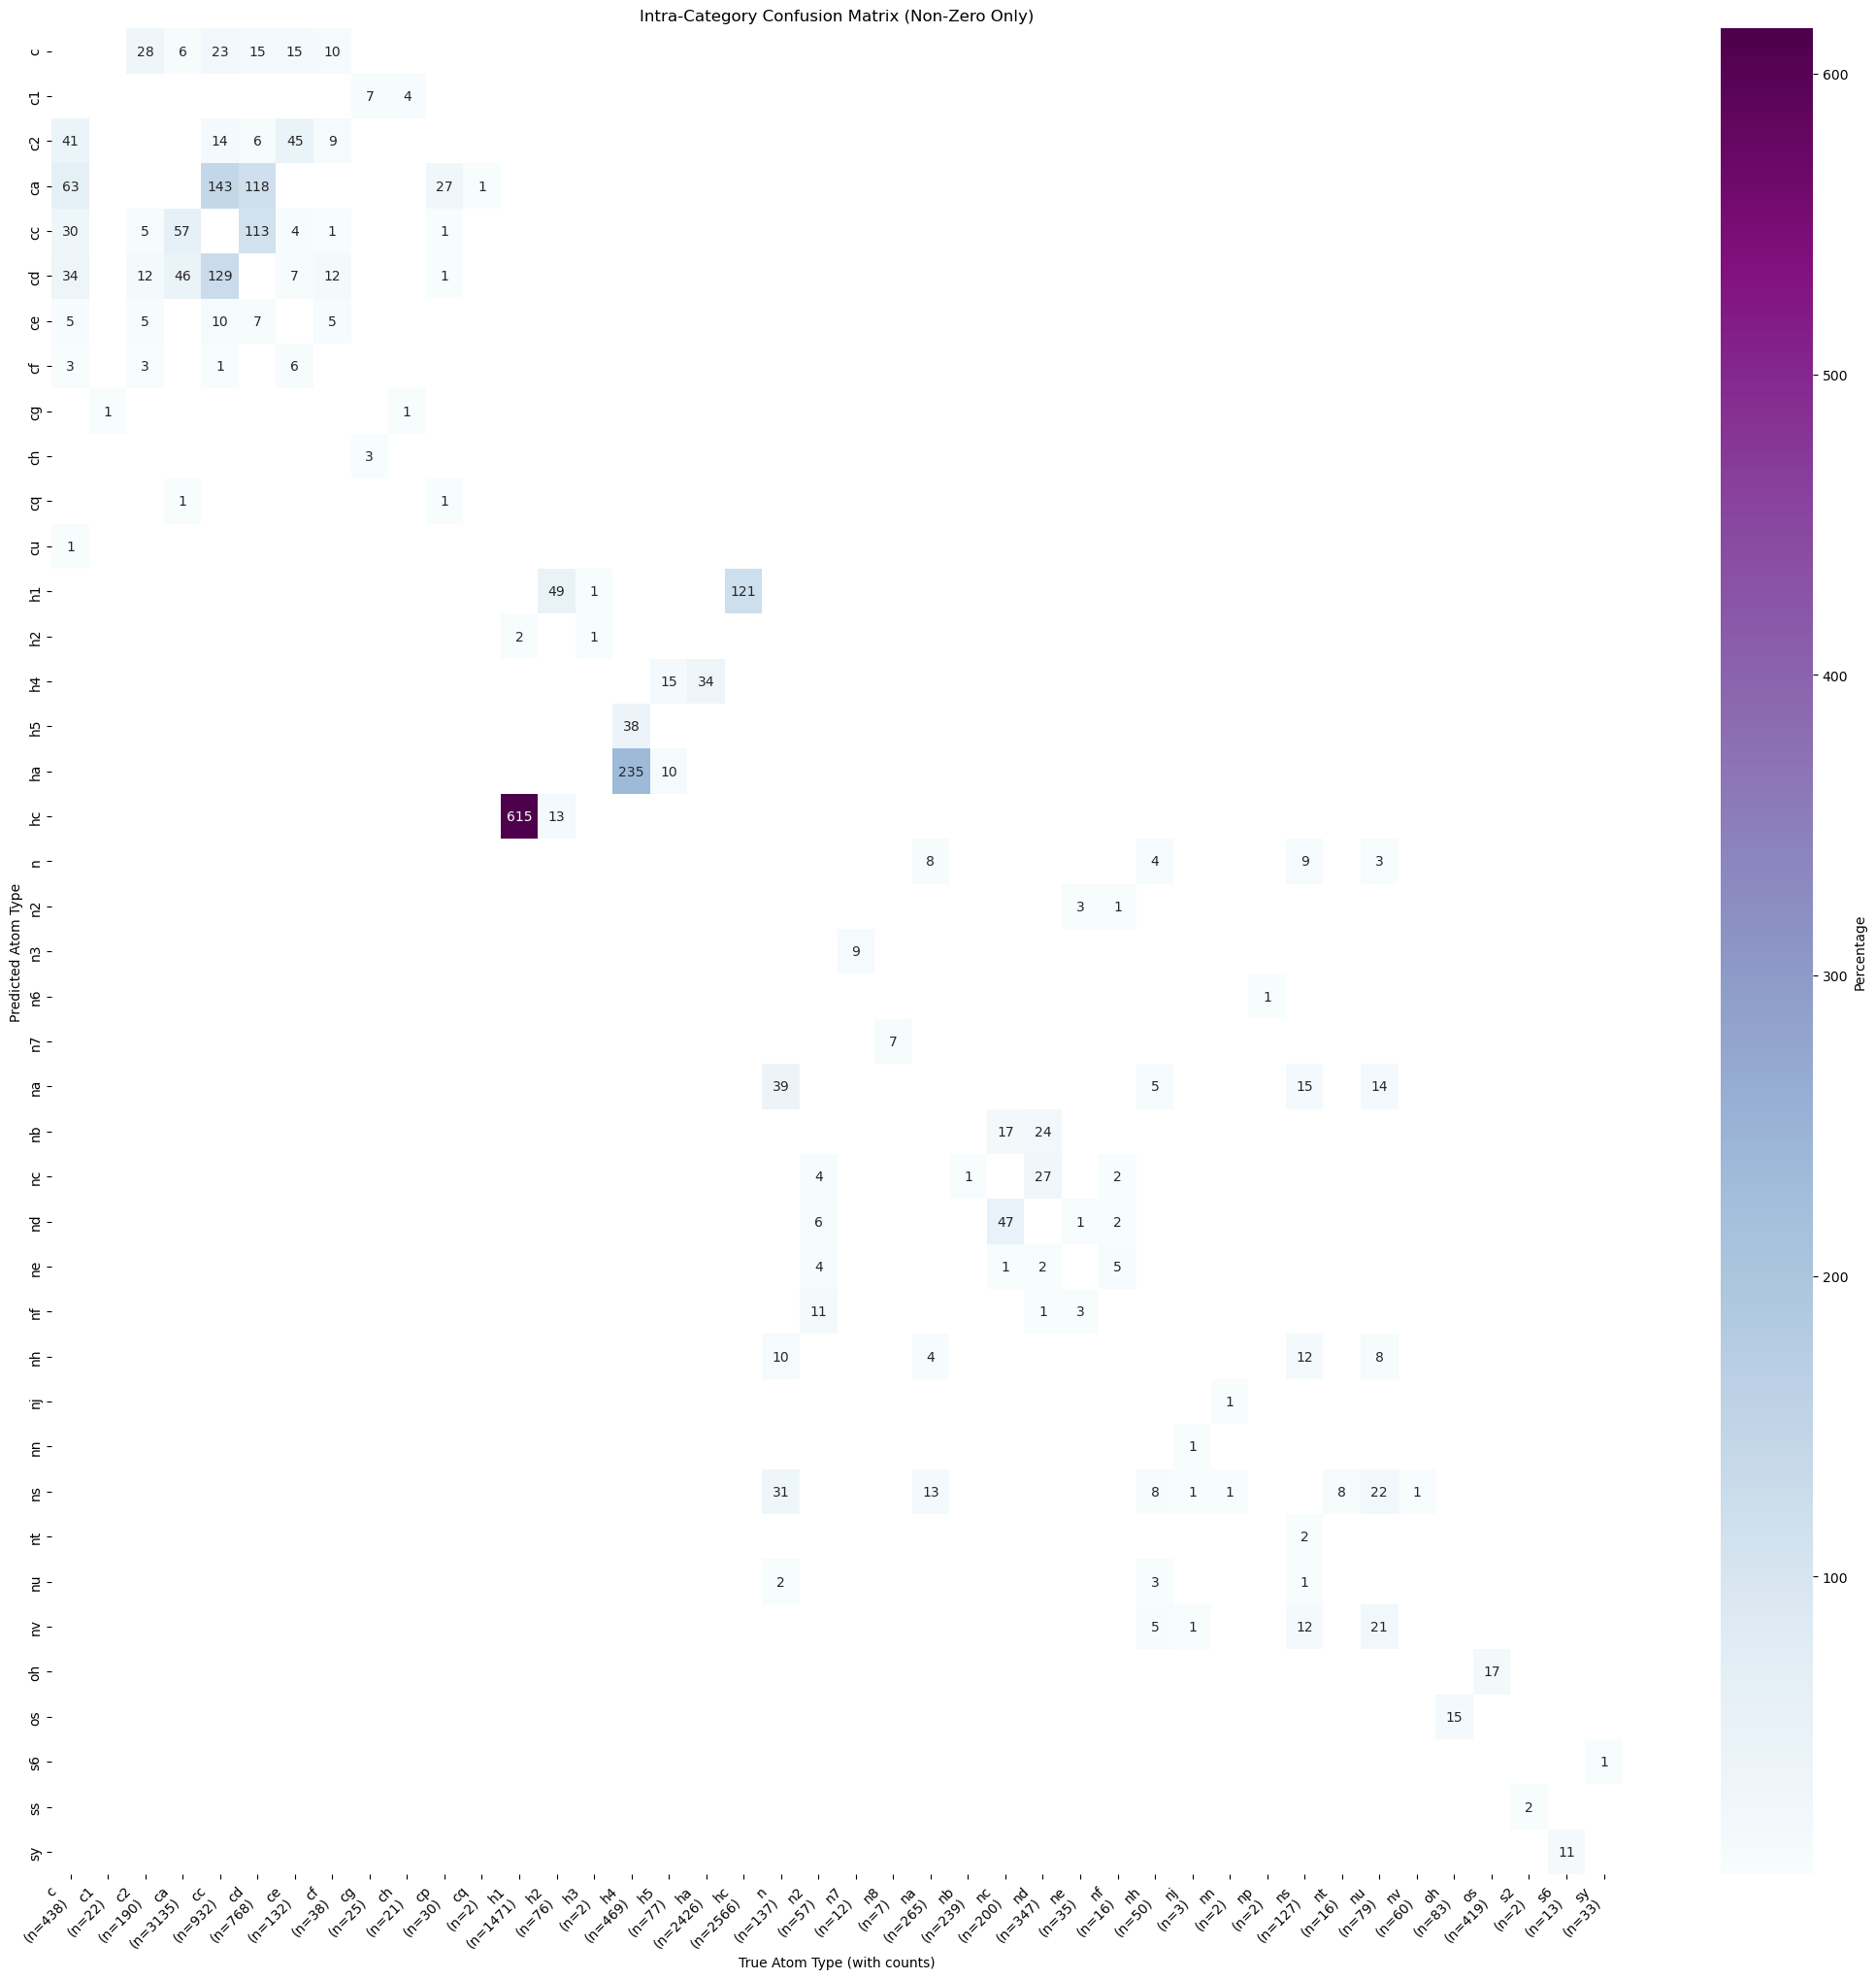

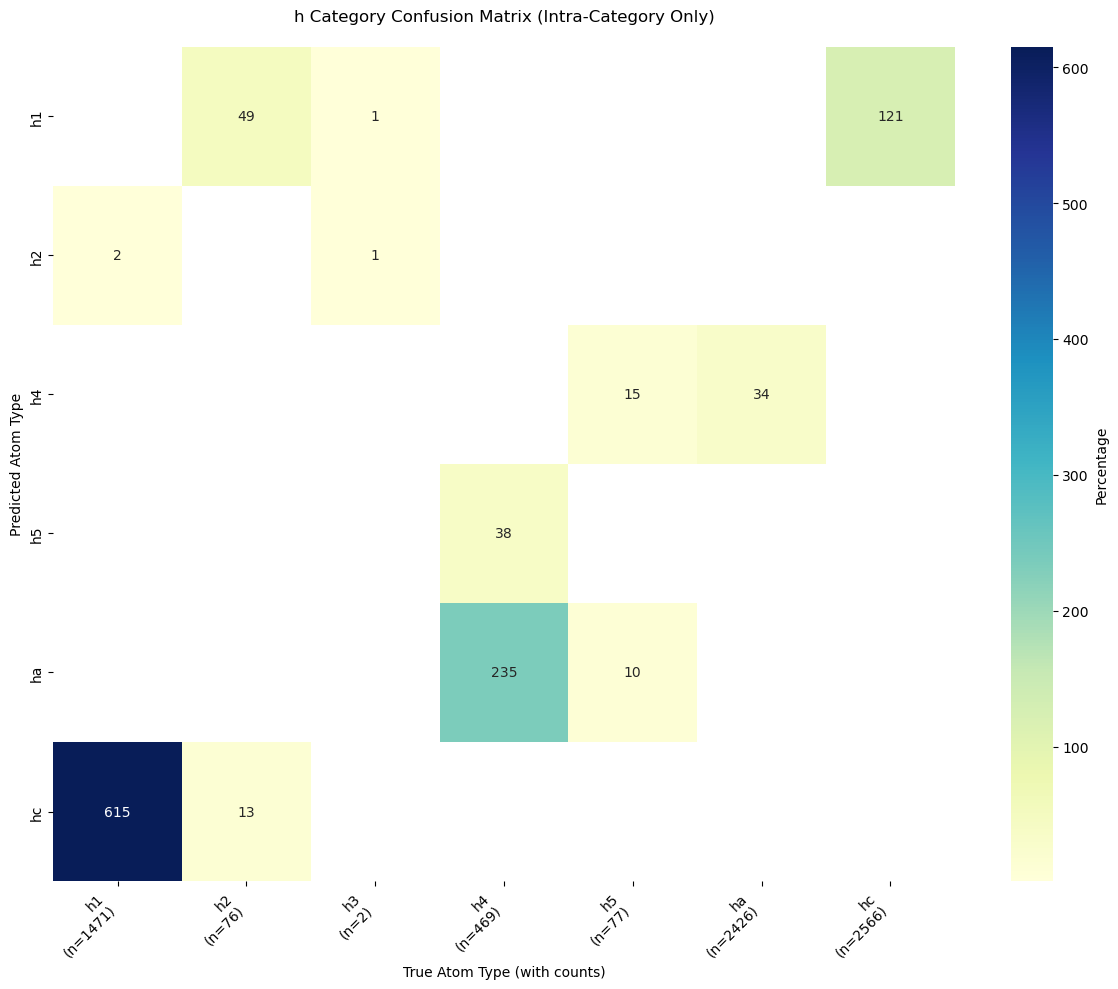

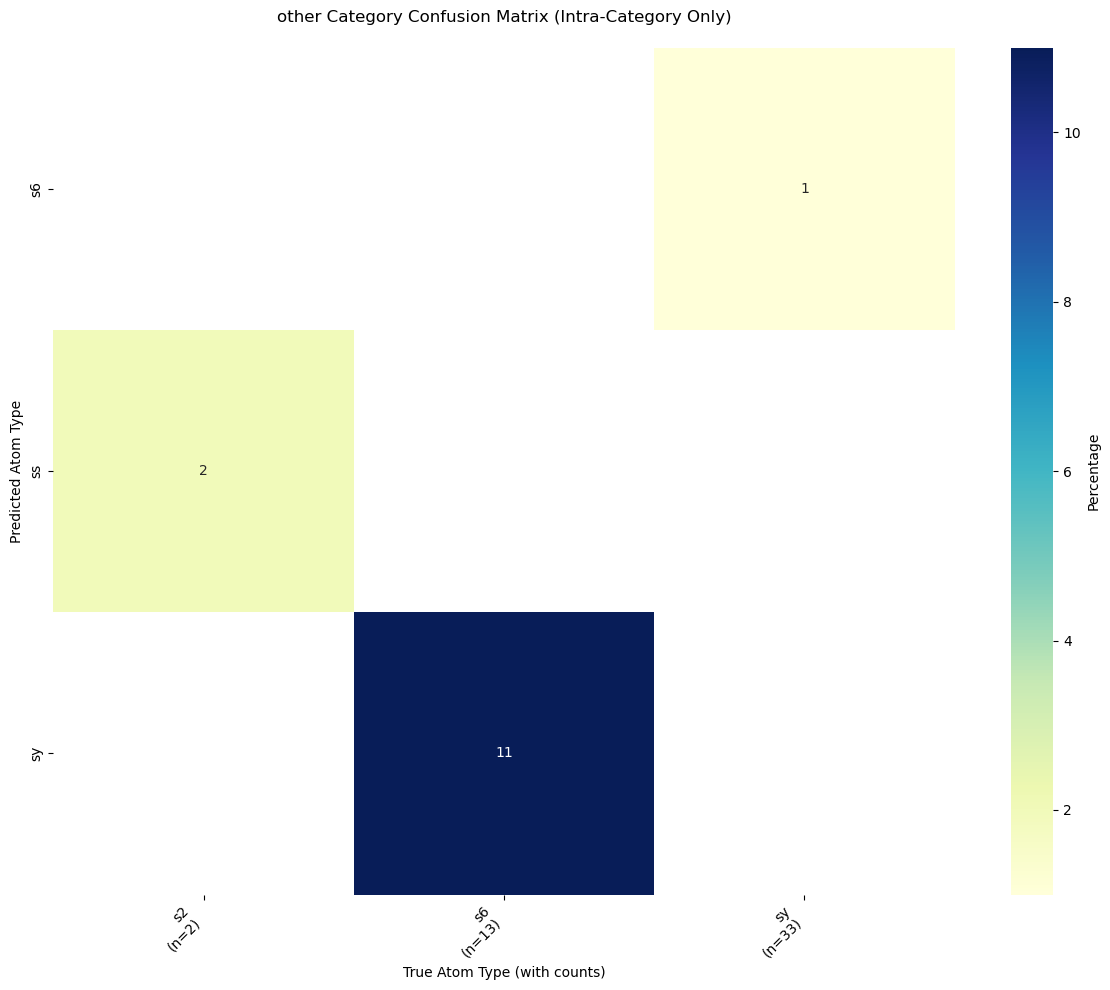

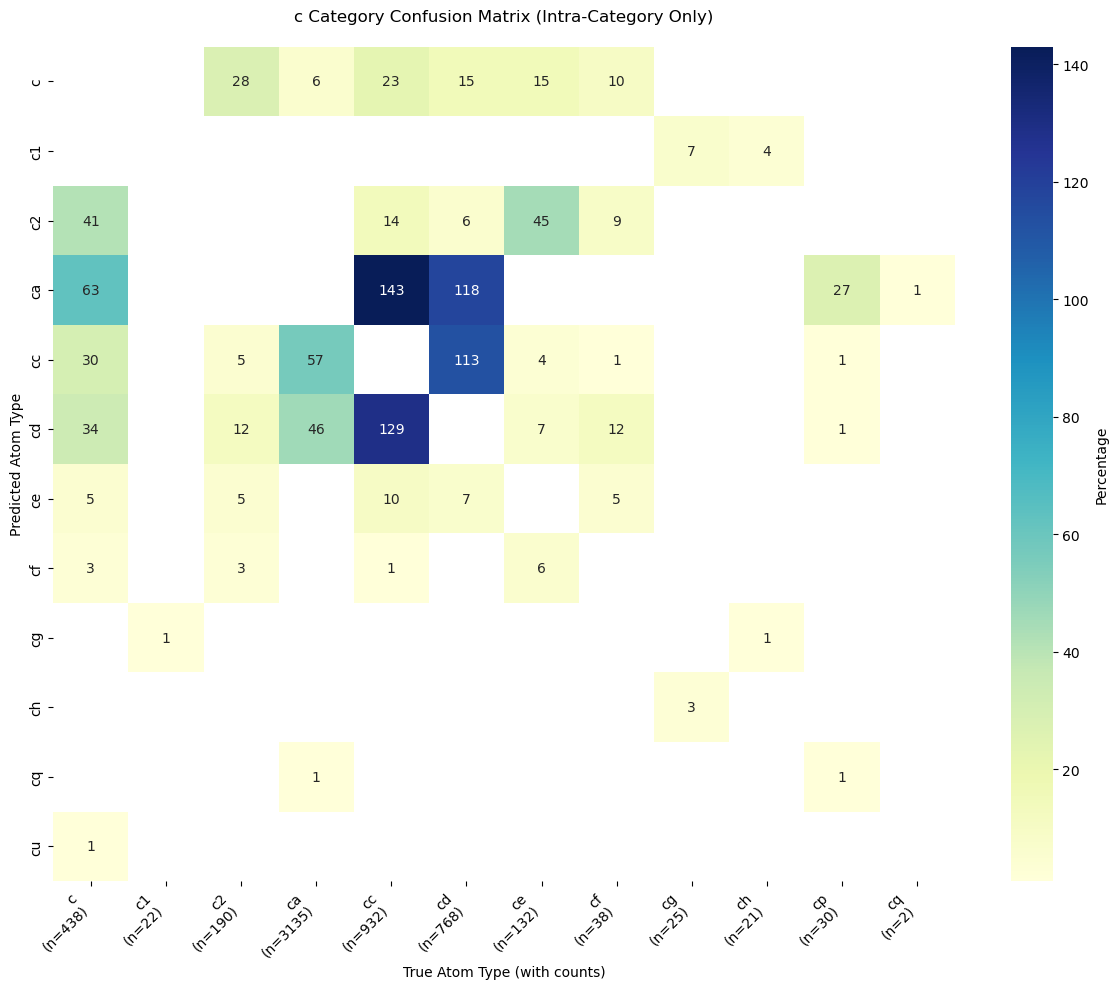

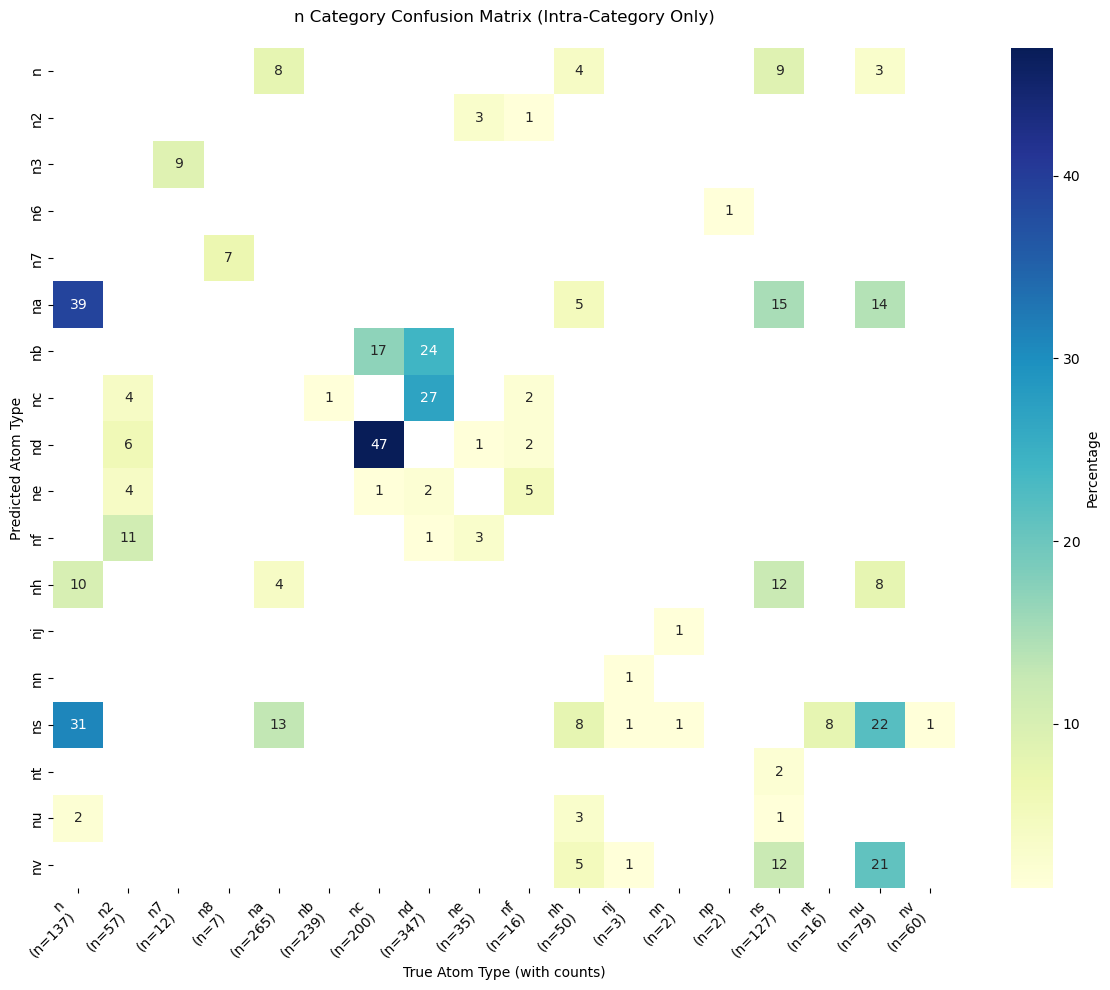

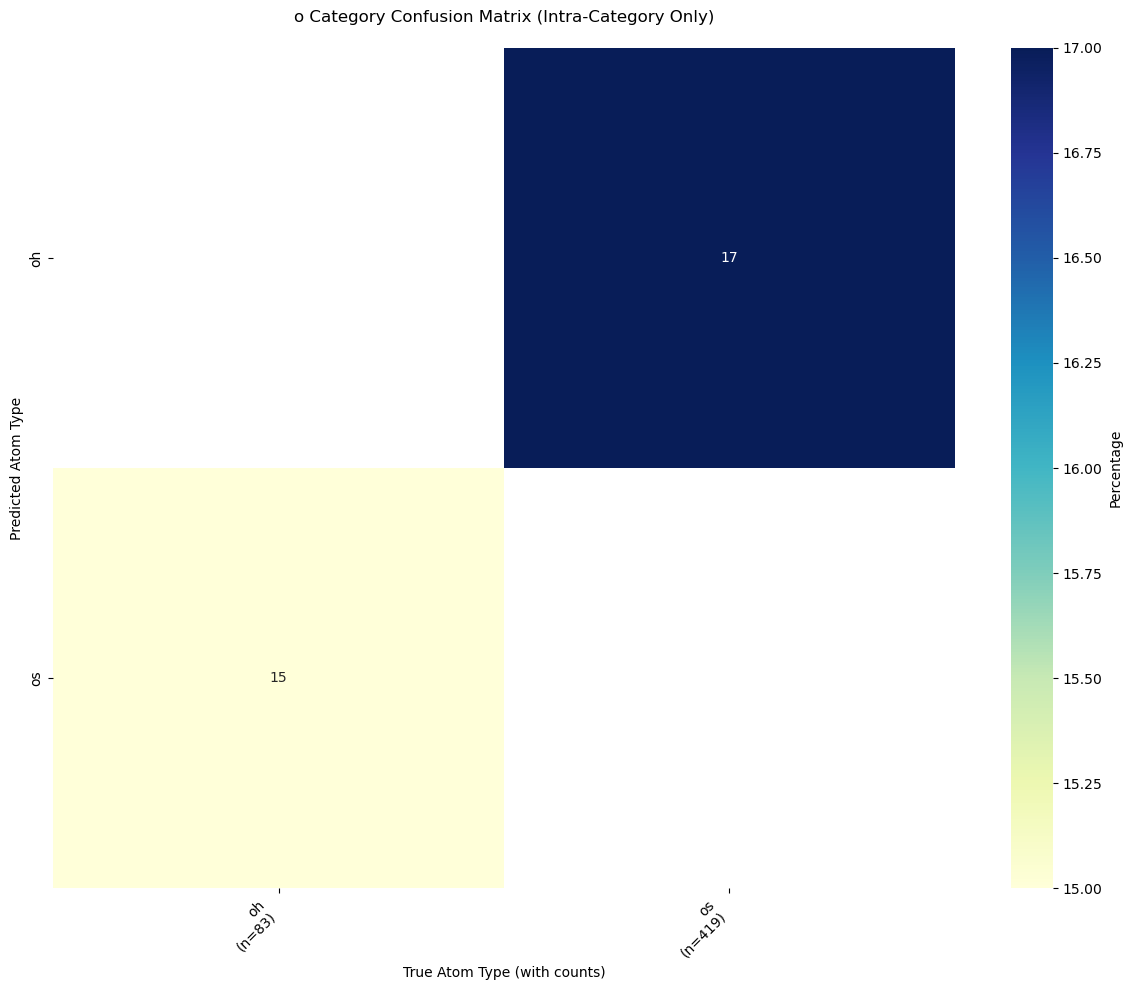

In [11]:
plot_full_cross_intra_confusion_matices(y_true=y_true_MPNN_4L, y_pred=y_pred_MPNN_4L)
plot_category_confusion_matrices(y_true=y_true_MPNN_4L, y_pred=y_pred_MPNN_4L)

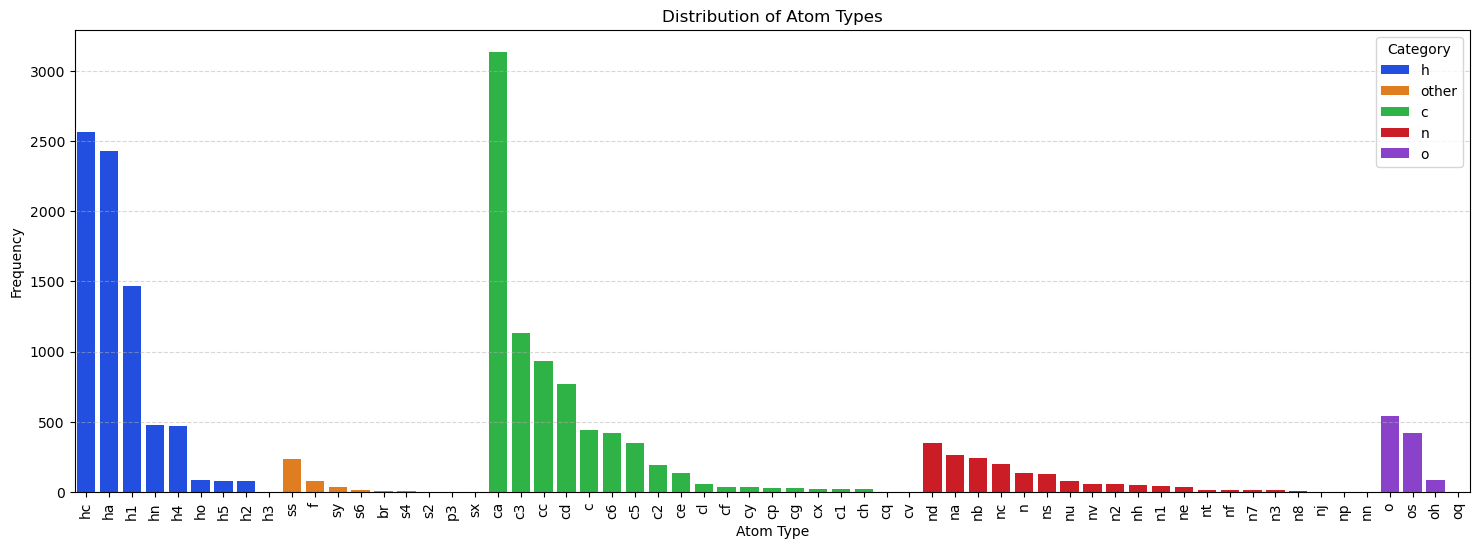

,Atom Type,Count,Category
0,hc,2566,h
1,ha,2426,h
2,h1,1471,h
3,hn,476,h
4,h4,469,h
...,...,...,...
56,nn,2,n
57,o,543,o
58,os,419,o
59,oh,83,o


In [12]:
all_y_values = []

for data in test_dataset:
    y_vals = data.y_values
    all_y_values.extend(y_vals)

# Now you can safely plot
plot_atom_distribution(np.array(all_y_values))
